In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import yaml
import os
from pathlib import Path

import warnings
warnings.filterwarnings("ignore")

sns.set_style("whitegrid")

In [112]:
df = pd.read_excel("../data/cleaned/df_cleaned.xlsx")
df.head()

,ENGINE SIZE,CYLINDERS,TRANSMISSION,FUEL,FUEL CONSUMPTION,COEMISSIONS,MAKE,MODEL
0,1.6,4,A4,X,10.5,216,ACURA,1.6EL
1,1.6,4,M5,X,9.8,205,ACURA,1.6EL
2,3.2,6,AS5,Z,13.7,265,ACURA,3.2TL
3,3.5,6,A4,Z,15.0,301,ACURA,3.5RL
4,1.8,4,A4,X,11.4,230,ACURA,INTEGRA


In [113]:
df.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
ENGINE SIZE,634.0,NaN,NaN,NaN,3.270978,1.232707,1.0,2.2,3.0,4.3,8.0
CYLINDERS,634.0,NaN,NaN,NaN,5.807571,1.626462,3.0,4.0,6.0,6.0,12.0
TRANSMISSION,634,8,A4,321,NaN,NaN,NaN,NaN,NaN,NaN,NaN
FUEL,634,5,X,452,NaN,NaN,NaN,NaN,NaN,NaN,NaN
FUEL CONSUMPTION,634.0,NaN,NaN,NaN,14.719401,3.308663,4.9,12.5,14.4,16.6,30.2
COEMISSIONS,634.0,NaN,NaN,NaN,296.895899,65.523378,104.0,253.0,288.0,343.0,582.0
MAKE,634,36,CHEVROLET,63,NaN,NaN,NaN,NaN,NaN,NaN,NaN
MODEL,634,327,LS,6,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [114]:
# Separating Dependent and Independent features
X = df.drop(labels='COEMISSIONS', axis=1)
y = df["COEMISSIONS"]

In [115]:
X.head()

,ENGINE SIZE,CYLINDERS,TRANSMISSION,FUEL,FUEL CONSUMPTION,MAKE,MODEL
0,1.6,4,A4,X,10.5,ACURA,1.6EL
1,1.6,4,M5,X,9.8,ACURA,1.6EL
2,3.2,6,AS5,Z,13.7,ACURA,3.2TL
3,3.5,6,A4,Z,15.0,ACURA,3.5RL
4,1.8,4,A4,X,11.4,ACURA,INTEGRA


In [116]:
y

0      216
1      205
2      265
3      301
4      230
      ... 
629    288
630    274
631    274
632    260
633    299
Name: COEMISSIONS, Length: 634, dtype: int64

## Train Test Split

In [117]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=123)

In [118]:
X_train.shape, y_train.shape

((507, 7), (507,))

In [119]:
X_test.shape, y_test.shape

((127, 7), (127,))

# Feature Engineering

In [120]:
X_train.head()

,ENGINE SIZE,CYLINDERS,TRANSMISSION,FUEL,FUEL CONSUMPTION,MAKE,MODEL
462,1.0,3,M5,X,7.1,PONTIAC,FIREFLY
270,3.0,6,A4,X,13.6,FORD,TAURUS
435,2.4,4,M5,X,14.9,NISSAN,FRONTIER 4X4
525,2.5,6,A4,X,14.2,SUZUKI,GRAND VITARA 4X4
190,3.9,6,M5,X,17.4,DODGE,RAM 1500


## Encoding Categorical features
- From EDA we have observed that Fuel Consimption and Coemssion have shown almost linear correlation i.e. if fuel consumption increases then coemssion also increases.
- So, we can encode the categorical features according to their respective mean fuel consumption.

- The mapping dictinoary is saved for fututre reference at the time of deployment.
- If a new input comes from the user which is not saved in the dictionary should be imputed with glodal mean of the training dataset.

In [121]:
CONFIG_FILEPATH="../config/column_config/"

In [122]:
# Claculating global fuel mean
global_mean = X_train['FUEL CONSUMPTION'].mean()
global_mean

np.float64(14.600591715976332)

In [123]:
data = {
    "global_mean": float(global_mean)
}

with open(CONFIG_FILEPATH+"global_mean.yaml", "w") as file:
    yaml.dump(data, file)

In [124]:
model_mean_fuel_cons = X_train.groupby(by=['MODEL'])['FUEL CONSUMPTION'].mean().to_dict()
model_mean_fuel_cons

{'1.6EL': 10.15,
 '3.2TL': 13.7,
 '3.5RL': 15.0,
 '323 CONVERTIBLE': 13.9,
 '323Ci': 13.4,
 '323i': 13.0,
 '328Ci': 13.45,
 '328i': 13.45,
 '456 MGT': 26.7,
 '456 MGTA': 26.5,
 '4RUNNER 4X4': 15.7,
 '528i': 13.8,
 '528i TOURING': 14.5,
 '540i': 15.549999999999999,
 '540i TOURING': 15.5,
 '550 MARANELLO': 30.2,
 '740iL': 15.4,
 '750iL': 19.1,
 '9-3 TURBO': 13.15,
 '9-5 TURBO': 13.799999999999999,
 '9-5 WAGON TURBO': 13.799999999999999,
 '911 CARRERA': 15.4,
 '911 CARRERA 4': 15.85,
 'A4': 12.149999999999999,
 'A4 QUATTRO': 13.766666666666666,
 'A6': 15.0,
 'A6 AVANT QUATTRO': 15.4,
 'A6 QUATTRO': 15.180000000000001,
 'A8 QUATTRO': 15.5,
 'ACCENT': 10.1,
 'ACCORD': 13.0,
 'ACCORD DX': 11.85,
 'ACCORD EX/LX': 11.8,
 'ALERO': 13.05,
 'ALTIMA': 12.2,
 'ASTRO AWD CARGO': 17.0,
 'ASTRO AWD PASSENGER': 17.4,
 'ASTRO CARGO': 16.2,
 'ASTRO PASSENGER': 17.7,
 'AVALON': 12.7,
 'B3000': 15.899999999999999,
 'B4000': 16.3,
 'B4000 4X4': 17.2,
 'BLAZER': 16.3,
 'BLAZER 4X4': 16.9,
 'BONNEVILLE': 14.4

In [125]:
X_train['MODEL'] = X_train['MODEL'].map(model_mean_fuel_cons)
X_train.head()

,ENGINE SIZE,CYLINDERS,TRANSMISSION,FUEL,FUEL CONSUMPTION,MAKE,MODEL
462,1.0,3,M5,X,7.1,PONTIAC,7.933333
270,3.0,6,A4,X,13.6,FORD,13.600000
435,2.4,4,M5,X,14.9,NISSAN,14.900000
525,2.5,6,A4,X,14.2,SUZUKI,14.000000
190,3.9,6,M5,X,17.4,DODGE,19.280000


In [126]:
make_mean_fuel_cons = X_train.groupby(by=['MAKE'])['FUEL CONSUMPTION'].mean().to_dict()
X_train['MAKE'] = X_train['MAKE'].map(make_mean_fuel_cons)
X_train.head()

,ENGINE SIZE,CYLINDERS,TRANSMISSION,FUEL,FUEL CONSUMPTION,MAKE,MODEL
462,1.0,3,M5,X,7.1,12.366667,7.933333
270,3.0,6,A4,X,13.6,16.240000,13.600000
435,2.4,4,M5,X,14.9,14.793333,14.900000
525,2.5,6,A4,X,14.2,11.072727,14.000000
190,3.9,6,M5,X,17.4,18.811111,19.280000


In [127]:
transmission_mean_fuel_cons = X_train.groupby(by=['TRANSMISSION'])['FUEL CONSUMPTION'].mean().to_dict()
X_train['TRANSMISSION'] = X_train['TRANSMISSION'].map(transmission_mean_fuel_cons)
X_train.head()

,ENGINE SIZE,CYLINDERS,TRANSMISSION,FUEL,FUEL CONSUMPTION,MAKE,MODEL
462,1.0,3,13.117610,X,7.1,12.366667,7.933333
270,3.0,6,15.290514,X,13.6,16.240000,13.600000
435,2.4,4,13.117610,X,14.9,14.793333,14.900000
525,2.5,6,15.290514,X,14.2,11.072727,14.000000
190,3.9,6,13.117610,X,17.4,18.811111,19.280000


In [128]:
fuel_type_mean_fuel_cons = X_train.groupby(by=['FUEL'])['FUEL CONSUMPTION'].mean().to_dict()
X_train['FUEL'] = X_train['FUEL'].map(fuel_type_mean_fuel_cons)
X_train.head()

,ENGINE SIZE,CYLINDERS,TRANSMISSION,FUEL,FUEL CONSUMPTION,MAKE,MODEL
462,1.0,3,13.117610,14.570637,7.1,12.366667,7.933333
270,3.0,6,15.290514,14.570637,13.6,16.240000,13.600000
435,2.4,4,13.117610,14.570637,14.9,14.793333,14.900000
525,2.5,6,15.290514,14.570637,14.2,11.072727,14.000000
190,3.9,6,13.117610,14.570637,17.4,18.811111,19.280000


## Saving the encoding mapping

In [129]:
data_list = [model_mean_fuel_cons, make_mean_fuel_cons, transmission_mean_fuel_cons, fuel_type_mean_fuel_cons]
file_list = ['car_model_config.yaml', 'car_make_config.yaml', 'transmission_config.yaml', 'fuel_config.yaml']

for data, file in zip(data_list, file_list):
    with open(CONFIG_FILEPATH+file, "w") as file:
        yaml.dump(data, file)

## Visualizing the distribution of numerical columns

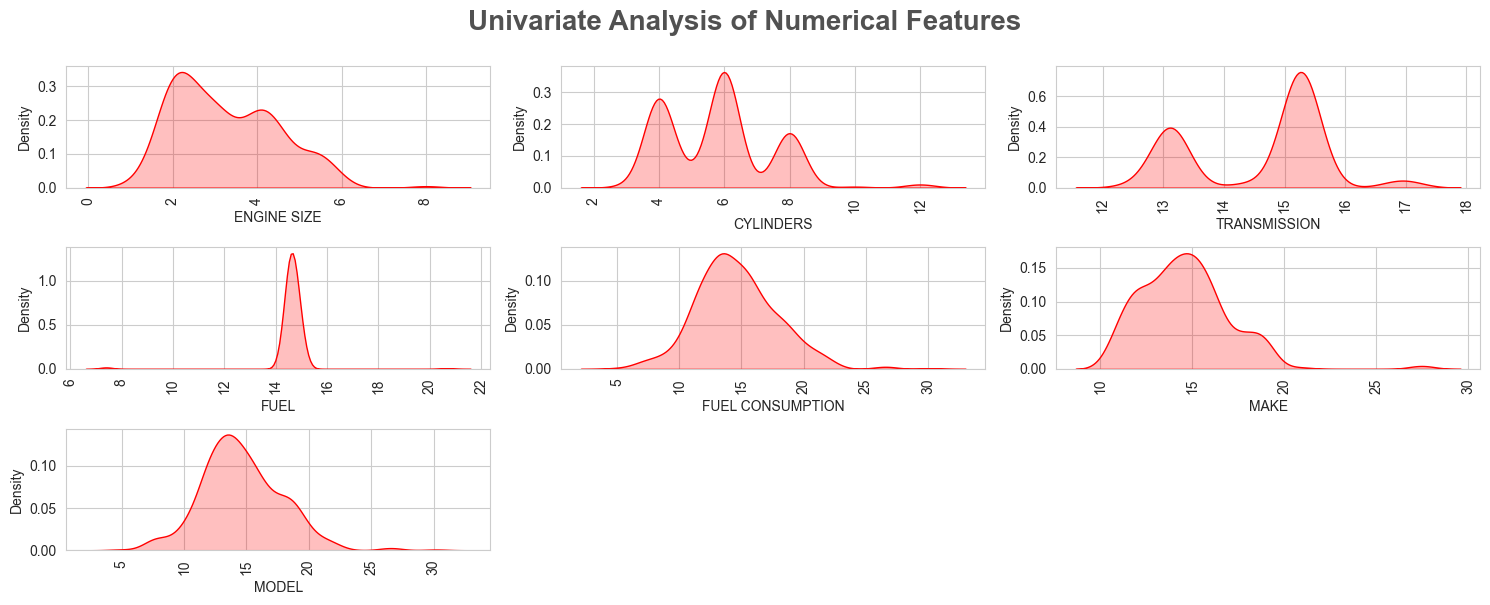

In [130]:
plt.figure(figsize=(15, 6))
plt.suptitle('Univariate Analysis of Numerical Features', fontsize=20, fontweight='bold', alpha=0.8, y=1)

for i,col in enumerate(X_train.columns):
    plt.subplot(3, 3, i+1)
    sns.kdeplot(data=X_train[col],fill=True, color='r')
    plt.xlabel(col)
    plt.xticks(rotation=90)
    plt.tight_layout()

In [131]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_train_scaled

array([[-1.83840091, -1.72098569, -1.33574586, ..., -2.2924591 ,
        -0.90874459, -2.07674717],
       [-0.20905162,  0.12761546,  0.62142415, ..., -0.30581795,
         0.66689946, -0.31166874],
       [-0.69785641, -1.1047853 , -1.33574586, ...,  0.09151028,
         0.0784059 ,  0.09326102],
       ...,
       [ 0.60562302,  1.36001623,  0.52059579, ...,  0.12207399,
         0.18959593,  0.12440946],
       [ 0.60562302,  0.12761546,  0.62142415, ...,  0.61109335,
         0.65062775,  0.43589389],
       [-0.61638894, -1.1047853 , -1.33574586, ..., -0.64201876,
        -1.00501888, -0.70102428]], shape=(507, 7))

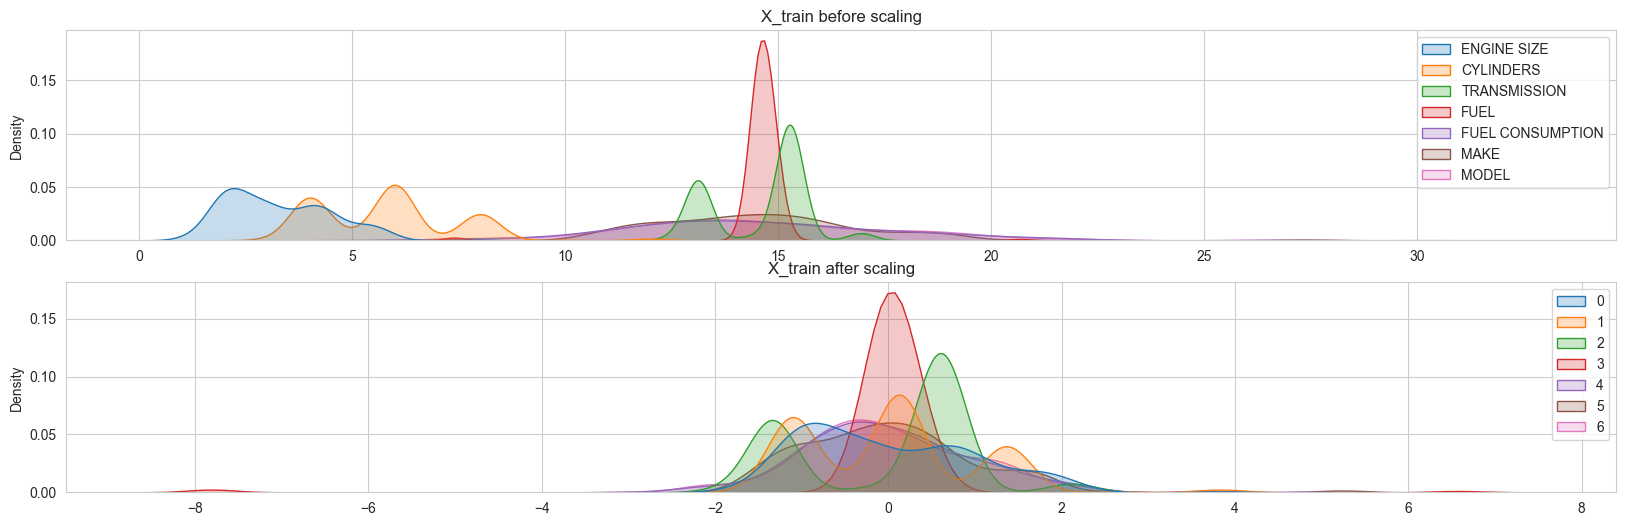

In [132]:
plt.figure(figsize=(20,6))
plt.subplot(2,1,1)
sns.kdeplot(data=X_train,fill=True)
plt.title("X_train before scaling")
plt.subplot(2,1,2)
sns.kdeplot(data=X_train_scaled,fill=True)
plt.title("X_train after scaling")
plt.show()

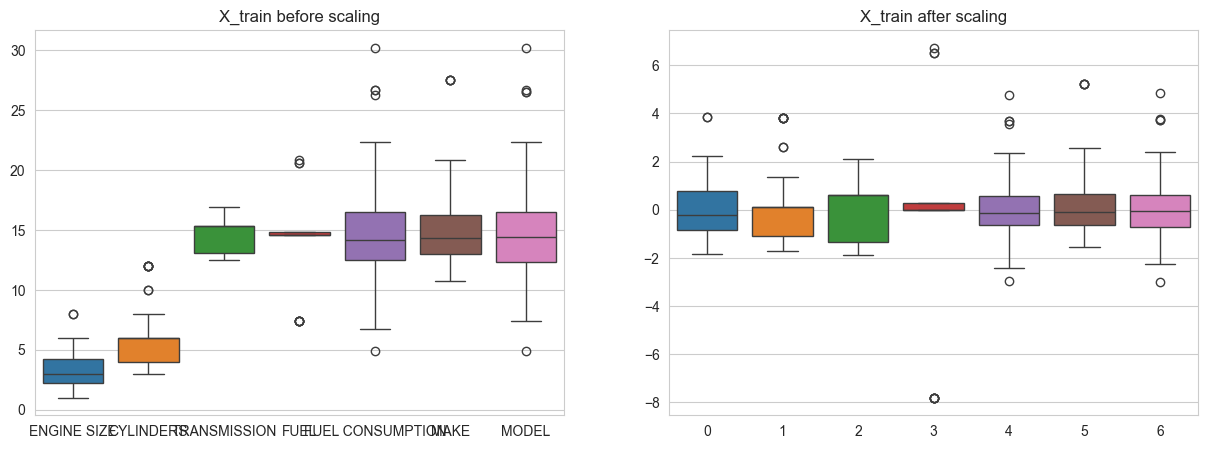

In [133]:
plt.figure(figsize=(15,5))
plt.subplot(1,2,1)
sns.boxplot(data=X_train)
plt.title("X_train before scaling")
plt.subplot(1,2,2)
sns.boxplot(data=X_train_scaled)
plt.title("X_train after scaling")
plt.show()

<Axes: xlabel='COEMISSIONS', ylabel='Density'>

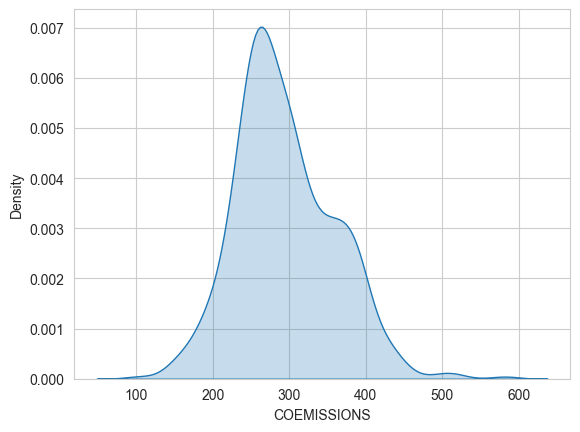

In [134]:
sns.kdeplot(data=y_train,fill=True)

In [135]:
y.skew()

np.float64(0.5281301236940938)

### Feature encoding on test data:
- Test data should be encoded according to the mapping generated from the training dataset.

In [136]:
# config loader
def config_loader(path=CONFIG_FILEPATH, file_list=None):
        all_configs = {} # Initializing empty disctionary
        keys = [i.split('_')[0] for i in file_list]
        for key, file in zip(keys, file_list):
                with open(path+file, "r") as f:
                        all_configs[key] = yaml.safe_load(f)
        return all_configs

In [137]:
all_configs = config_loader(file_list=os.listdir(CONFIG_FILEPATH))
all_configs

{'car': {'1.6EL': 10.15,
  '3.2TL': 13.7,
  '3.5RL': 15.0,
  '323 CONVERTIBLE': 13.9,
  '323Ci': 13.4,
  '323i': 13.0,
  '328Ci': 13.45,
  '328i': 13.45,
  '456 MGT': 26.7,
  '456 MGTA': 26.5,
  '4RUNNER 4X4': 15.7,
  '528i': 13.8,
  '528i TOURING': 14.5,
  '540i': 15.549999999999999,
  '540i TOURING': 15.5,
  '550 MARANELLO': 30.2,
  '740iL': 15.4,
  '750iL': 19.1,
  '9-3 TURBO': 13.15,
  '9-5 TURBO': 13.799999999999999,
  '9-5 WAGON TURBO': 13.799999999999999,
  '911 CARRERA': 15.4,
  '911 CARRERA 4': 15.85,
  'A4': 12.149999999999999,
  'A4 QUATTRO': 13.766666666666666,
  'A6': 15.0,
  'A6 AVANT QUATTRO': 15.4,
  'A6 QUATTRO': 15.180000000000001,
  'A8 QUATTRO': 15.5,
  'ACCENT': 10.1,
  'ACCORD': 13.0,
  'ACCORD DX': 11.85,
  'ACCORD EX/LX': 11.8,
  'ALERO': 13.05,
  'ALTIMA': 12.2,
  'ASTRO AWD CARGO': 17.0,
  'ASTRO AWD PASSENGER': 17.4,
  'ASTRO CARGO': 16.2,
  'ASTRO PASSENGER': 17.7,
  'AVALON': 12.7,
  'B3000': 15.899999999999999,
  'B4000': 16.3,
  'B4000 4X4': 17.2,
  'BLAZ

In [138]:
all_configs.keys()

dict_keys(['car', 'fuel', 'global', 'make', 'model', 'transmission'])

In [139]:
X_test.head()

,ENGINE SIZE,CYLINDERS,TRANSMISSION,FUEL,FUEL CONSUMPTION,MAKE,MODEL
326,2.0,4,A4,X,12.5,HONDA,CR-V
542,2.2,4,A4,X,11.8,TOYOTA,CAMRY SOLARA
151,3.8,6,A4,X,15.2,CHRYSLER,TOWN & COUNTRY
134,3.5,6,AS4,X,14.4,CHRYSLER,300M
308,4.3,6,A4,X,17.7,GMC,SAFARI PASSENGER


In [140]:
X_test.dtypes

ENGINE SIZE         float64
CYLINDERS             int64
TRANSMISSION            str
FUEL                    str
FUEL CONSUMPTION    float64
MAKE                    str
MODEL                   str
dtype: object

In [ ]:
test_cat_col = [col for col in X_test.columns if X_test[col].dtypes=='str']
test_cat_col

['TRANSMISSION', 'FUEL', 'MAKE', 'MODEL']

In [142]:
# Encode Model
def encode_model(x):
    if x in (all_configs['model'].keys()):
        return all_configs['model'][x]
    else:
        return all_configs['global']['global_mean']
    
X_test['MODEL'] = X_test['MODEL'].apply(lambda x: encode_model(x))
X_test.head()

,ENGINE SIZE,CYLINDERS,TRANSMISSION,FUEL,FUEL CONSUMPTION,MAKE,MODEL
326,2.0,4,A4,X,12.5,HONDA,12.500000
542,2.2,4,A4,X,11.8,TOYOTA,13.050000
151,3.8,6,A4,X,15.2,CHRYSLER,14.600592
134,3.5,6,AS4,X,14.4,CHRYSLER,14.600592
308,4.3,6,A4,X,17.7,GMC,14.600592


In [143]:
# Encode Make
def encode_model(x):
    if x in (all_configs['make'].keys()):
        return all_configs['make'][x]
    else:
        return all_configs['global']['global_mean']
    
X_test['MAKE'] = X_test['MAKE'].apply(lambda x: encode_model(x))
X_test.head()

,ENGINE SIZE,CYLINDERS,TRANSMISSION,FUEL,FUEL CONSUMPTION,MAKE,MODEL
326,2.0,4,A4,X,12.5,10.978571,12.500000
542,2.2,4,A4,X,11.8,13.034375,13.050000
151,3.8,6,A4,X,15.2,13.353333,14.600592
134,3.5,6,AS4,X,14.4,13.353333,14.600592
308,4.3,6,A4,X,17.7,17.645161,14.600592


In [144]:
# Encode Transmission
def encode_model(x):
    if x in (all_configs['transmission'].keys()):
        return all_configs['transmission'][x]
    else:
        return all_configs['global']['global_mean']
    
X_test['TRANSMISSION'] = X_test['TRANSMISSION'].apply(lambda x: encode_model(x))
X_test.head()

,ENGINE SIZE,CYLINDERS,TRANSMISSION,FUEL,FUEL CONSUMPTION,MAKE,MODEL
326,2.0,4,15.290514,X,12.5,10.978571,12.500000
542,2.2,4,15.290514,X,11.8,13.034375,13.050000
151,3.8,6,15.290514,X,15.2,13.353333,14.600592
134,3.5,6,14.370000,X,14.4,13.353333,14.600592
308,4.3,6,15.290514,X,17.7,17.645161,14.600592


In [145]:
# Encode Transmission
def encode_model(x):
    if x in (all_configs['fuel'].keys()):
        return all_configs['fuel'][x]
    else:
        return all_configs['global']['global_mean']
    
X_test['FUEL'] = X_test['FUEL'].apply(lambda x: encode_model(x))
X_test.head()

,ENGINE SIZE,CYLINDERS,TRANSMISSION,FUEL,FUEL CONSUMPTION,MAKE,MODEL
326,2.0,4,15.290514,14.570637,12.5,10.978571,12.500000
542,2.2,4,15.290514,14.570637,11.8,13.034375,13.050000
151,3.8,6,15.290514,14.570637,15.2,13.353333,14.600592
134,3.5,6,14.370000,14.570637,14.4,13.353333,14.600592
308,4.3,6,15.290514,14.570637,17.7,17.645161,14.600592


In [146]:
X_test.sample(20)

,ENGINE SIZE,CYLINDERS,TRANSMISSION,FUEL,FUEL CONSUMPTION,MAKE,MODEL
299,4.3,6,13.117610,14.570637,18.7,17.645161,18.400000
273,3.0,6,15.290514,14.570637,14.0,16.240000,14.600592
166,3.3,6,15.290514,14.570637,14.5,18.811111,20.600000
9,1.8,4,15.178571,14.862044,12.9,14.178947,12.150000
363,4.0,8,15.178571,14.862044,15.7,15.711111,14.600592
369,2.5,4,12.514286,14.570637,16.6,16.200000,16.233333
308,4.3,6,15.290514,14.570637,17.7,17.645161,14.600592
177,5.9,8,15.290514,14.570637,22.3,18.811111,18.575000
31,2.5,6,15.178571,14.862044,14.6,14.518182,13.900000
421,4.3,8,15.178571,14.862044,15.1,14.318750,14.600592


### Model Training

In [147]:
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import Pipeline

linear_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LinearRegression())
])

linear_pipeline.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('scaler', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None


In [148]:
y_pred = linear_pipeline.predict(X_test)

In [149]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import math

mse = mean_squared_error(y_test, y_pred)
rmse = math.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

performance_matrix = pd.DataFrame({"Values":[mse,rmse,mae,r2]}, index=["MSE","RMSE","MAE","R2 Score"])
performance_matrix

,Values
MSE,100.583944
RMSE,10.029155
MAE,8.140326
R2 Score,0.978570


In [152]:
from sklearn.linear_model import ElasticNet
from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import RobustScaler, PowerTransformer

# 1️⃣ Build pipeline
pipeline = Pipeline([
    ("power", PowerTransformer(method="yeo-johnson")),  # handles skewness
    ("scaler", RobustScaler()),                         # robust to outliers
    ("model", ElasticNet(max_iter=10000))
])

# 2️⃣ Define parameter grid
param_grid = {
    "model__alpha": np.logspace(-4, 1, 20),   # regularization strength
    "model__l1_ratio": np.linspace(0.1, 0.9, 9)  # L1 vs L2 mix
}

# 3️⃣ Grid search
grid = GridSearchCV(
    estimator=pipeline,
    param_grid=param_grid,
    cv=5,
    scoring="neg_mean_squared_error",
    n_jobs=-1,
    verbose=True
)

# 4️⃣ Fit
grid.fit(X_train, y_train)

Fitting 5 folds for each of 180 candidates, totalling 900 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...iter=10000))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'model__alpha': array([1.0000...00000000e+01]), 'model__l1_ratio': array([0.1, 0....7, 0.8, 0.9])}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'neg_mean_squared_error'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter can

In [153]:
print("Best parameters:", grid.best_params_)

Best parameters: {'model__alpha': np.float64(0.0001), 'model__l1_ratio': np.float64(0.9)}


In [158]:
grid.feature_names_in_

array(['ENGINE SIZE', 'CYLINDERS', 'TRANSMISSION', 'FUEL',
       'FUEL CONSUMPTION', 'MAKE', 'MODEL'], dtype=object)

In [164]:
data = {}

for key, value in grid.best_params_.items(): # Updating best parameters
    data[key] = float(value)

data['inputs'] = list(grid.feature_names_in_) # Updationg input columns

ARTIFACT_PATH="../config/model_config/"

with open(ARTIFACT_PATH+"artifact_config.yaml", "w") as f:
    yaml.dump(data, f)

In [156]:
y_pred = grid.predict(X_test)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
print("Test RMSE:", rmse)

Test RMSE: 9.763052630959955


In [157]:
r2_score(y_test, y_pred)

0.9796922700809124

#### Assumption-1: scatter plot between y_test and y_pred should show linear pattern

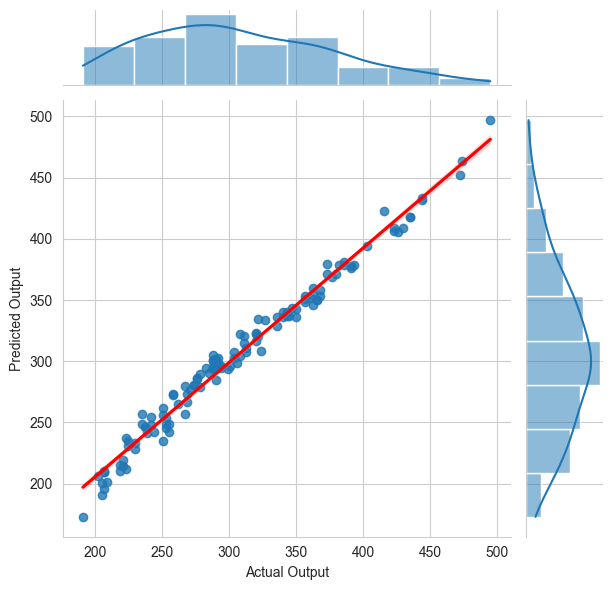

In [159]:
sns.jointplot(x=y_test, y=y_pred, kind='reg', line_kws={"color": "red"})
plt.xlabel("Actual Output")
plt.ylabel("Predicted Output")
plt.show()

#### Assumption-2: Density plot of residuals should be normaly distributed

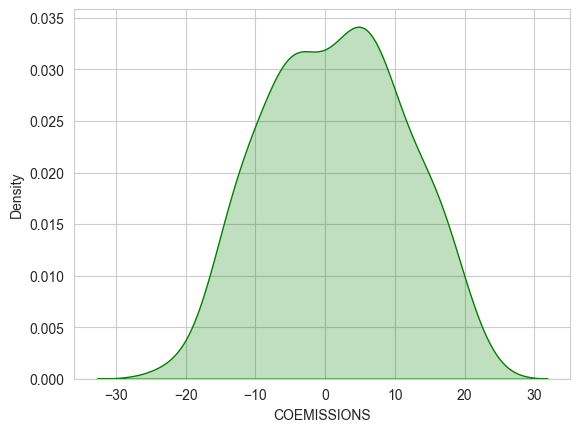

In [160]:
residuals = y_test - y_pred

# densityplot this residuals
sns.kdeplot(data=residuals,fill=True, color='g')
plt.show()

#### Assumption-3: scatter plot between y_pred and residuals should be unformly distributed i.e. no pattern

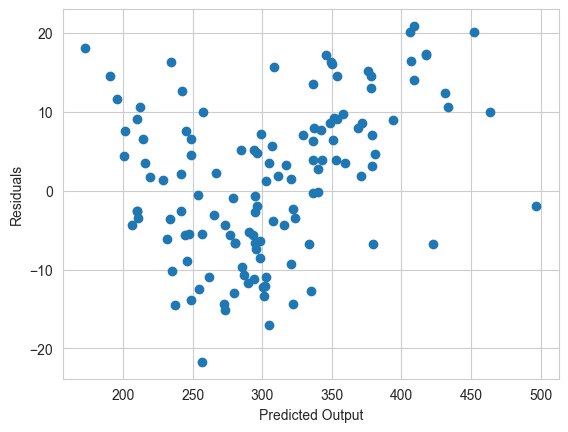

In [161]:
# scatter plot with respect to prediction and residuals
plt.scatter(x=y_pred, y=residuals)
plt.xlabel("Predicted Output")
plt.ylabel("Residuals")
plt.show()

In [162]:
import statsmodels.api as sm

model = sm.OLS(endog=y_train, exog=X_train).fit()
model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                                 OLS Regression Results                                
=======================================================================================
Dep. Variable:            COEMISSIONS   R-squared (uncentered):                   0.998
Model:                            OLS   Adj. R-squared (uncentered):              0.998
Method:                 Least Squares   F-statistic:                          4.599e+04
Date:                Thu, 05 Mar 2026   Prob (F-statistic):                        0.00
Time:                        15:49:37   Log-Likelihood:                         -1973.5
No. Observations:                 507   AIC:                                      3961.
Df Residuals:                     500   BIC:                                      3991.
Df Model:                           7                                                  
Covariance Type:            nonrobust                                                  
====================================================================================
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
ENGINE SIZE          1.3618      1.126      1.209      0.227      -0.851       3.575
CYLINDERS           -2.9650      0.757     -3.914      0.000      -4.453      -1.477
TRANSMISSION         2.8875      0.407      7.089      0.000       2.087       3.688
FUEL                -2.3117      0.432     -5.352      0.000      -3.160      -1.463
FUEL CONSUMPTION    17.0227      0.892     19.088      0.000      15.271      18.775
MAKE                -0.2024      0.324     -0.624      0.533      -0.839       0.435
MODEL                3.6108      0.876      4.124      0.000       1.890       5.331
==============================================================================
Omnibus:                      476.842   Durbin-Watson:                   2.031
Prob(Omnibus):                  0.000   Jarque-Bera (JB):            28828.350
Skew:                          -3.845   Prob(JB):                         0.00
Kurtosis:                      39.132   Cond. No.                         79.8
==============================================================================

Notes:
[1] R² is computed without centering (uncentered) since the model does not contain a constant.
[2] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [163]:
import pickle

with open("../artifacts/model.pkl", "wb") as f:
    pickle.dump(grid, f)